# BioAge — Resoconto del progetto: dall'Età Cronologica all'Età Biologica
### Modello di invecchiamento su coorte clinica di uno studio medico, validato sul pool NHANES 2007–2020

**Obiettivo.** Stimare l'**età biologica** dei pazienti dai biomarcatori di routine. Il principio: un modello
addestrato a riconoscere l'**invecchiamento sano** predice bene l'età anagrafica di chi è sano, ma assegna a
chi ha biomarcatori alterati un'età *più alta* — ed è proprio questo scarto la sua **età biologica**.

Percorso del notebook (7 step): caricamento → pulizia **biologica** → model selection → il *paradosso* del
MAE → validazione esterna su **NHANES multi-ciclo** → feature selection → richiesta formale allo studio medico.

## Step 1 — Introduzione e caricamento dati

**Età cronologica vs biologica.** L'età cronologica (`CA`) è il tempo trascorso dalla nascita; l'età biologica
(`BA`) riflette lo *stato* dell'organismo. Due persone della stessa `CA` possono avere `BA` molto diverse a
seconda di metabolismo, infiammazione, funzione d'organo. Partiamo dal dataset clinico di Bergamo
`df_clean_con_indici.csv` (esami di routine + indici derivati).

In [24]:
import warnings, os
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
sns.set_theme(style="whitegrid", context="notebook")
SEED=42; np.random.seed(SEED)
os.makedirs("outputs_resoconto/figures", exist_ok=True)

raw = pd.read_csv("df_clean_con_indici.csv", encoding="latin-1")
age_col = [c for c in raw.columns if c.startswith("Et")][0]
df = raw.rename(columns={age_col:"Eta", "Alanina aminotransferasi (ALT)":"ALT",
                         "Aspartato Aminotransferasi (AST)":"AST"})
df["sex_bin"] = (df["Genere"]=="M").astype(int)
print(f"Record: {df.shape[0]} | Pazienti: {df['id_num'].nunique()} | Eta' {int(df.Eta.min())}-{int(df.Eta.max())}")
df[["id_num","Eta","Genere","Glucosio","Creatinina","Colesterolo totale","ALT"]].head()

Record: 15718 | Pazienti: 12050 | Eta' 18-103


,id_num,Eta,Genere,Glucosio,Creatinina,Colesterolo totale,ALT
0,1,55,M,129,0.78,222,26
1,2,85,M,108,1.11,130,33
2,3,54,F,181,0.80,158,21
3,4,57,F,86,0.74,191,16
4,5,48,F,96,0.78,206,11


### La coorte in numeri

Prima di procedere, una fotografia della popolazione clinica: **distribuzione dell'età** (con l'età media) e
**composizione per genere**. La coorte è ampia e ben distribuita sull'arco adulto, con una lieve prevalenza
femminile.

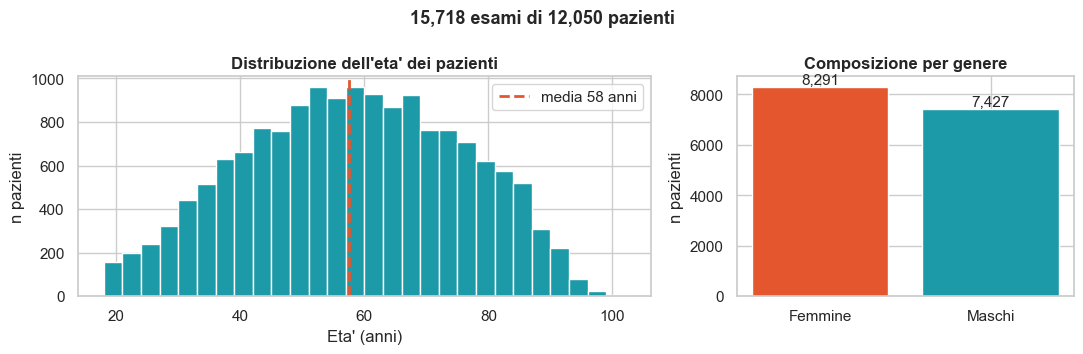

In [25]:
# === Panoramica della coorte: distribuzione dell'eta' + composizione per genere ===
n_esami    = len(df)
n_pazienti = df["id_num"].nunique()
eta_media  = df["Eta"].mean()
gen = df["Genere"].value_counts()
n_f, n_m = int(gen.get("F", 0)), int(gen.get("M", 0))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.7, 1]})
fig.suptitle(f"{n_esami:,} esami di {n_pazienti:,} pazienti", fontsize=13, fontweight="bold")

# -- sinistra: distribuzione dell'eta'
ax[0].hist(df["Eta"], bins=range(int(df.Eta.min()), int(df.Eta.max()) + 2, 3),
           color="#1C9AA8", edgecolor="white")
ax[0].axvline(eta_media, color="#E4572E", ls="--", lw=2, label=f"media {eta_media:.0f} anni")
ax[0].set_title("Distribuzione dell'eta' dei pazienti", fontweight="bold")
ax[0].set_xlabel("Eta' (anni)"); ax[0].set_ylabel("n pazienti"); ax[0].legend()

# -- destra: composizione per genere
b = ax[1].bar(["Femmine", "Maschi"], [n_f, n_m], color=["#E4572E", "#1C9AA8"])
ax[1].set_title("Composizione per genere", fontweight="bold"); ax[1].set_ylabel("n pazienti")
for rect, v in zip(b, [n_f, n_m]):
    ax[1].text(rect.get_x() + rect.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("outputs_resoconto/figures/r_demografia.png", dpi=110)
plt.show()

## Step 2 — Pulizia del dataset: criterio **biologico**, non statistico

Questa è la decisione metodologica più importante. Vogliamo una coorte di **invecchiamento sano**, quindi
selezioniamo i pazienti i cui biomarcatori sono nei **range clinici di normalità**, *stratificati per fascia
d'età*: per ogni fascia e per ogni marcatore definiamo un intervallo di tolleranza (con lievi adattamenti
fisiologici nelle fasce anziane per glicemia, creatinina, urea, RDW).

**Perché NON usiamo metodi statistici (IQR, z-score).** Un outlier statistico non è un paziente patologico, e
viceversa: un valore nel terzo quartile può essere *statisticamente normale ma clinicamente alterato* (es. una
glicemia di 124 mg/dL è dentro la distribuzione ma è già pre-diabete). Rimuovere per IQR butterebbe via
informazione clinica e terrebbe dentro pazienti malati. Il filtro è **medico**: dentro/fuori dai range di
riferimento. Otteniamo due dataset: `df_completo` (sani **e** malati) e `df_sano` (solo nei range biologici).

df_completo (sani + malati): 15718
df_sano (tutti i marker nei range biologici): 3495 (22.2%)
        totale  sani  % sani
fascia                      
18-39     2721  1073    39.4
40-54     4116   902    21.9
55-69     4549   642    14.1
70+       4332   878    20.3


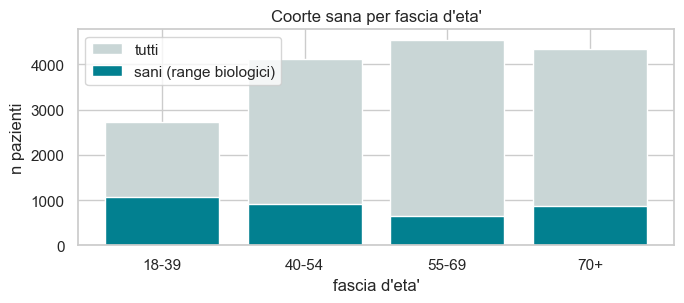

In [26]:
AGE_BANDS = [(18,39),(40,54),(55,69),(70,200)]
BAND_LBL  = ["18-39","40-54","55-69","70+"]
# range clinici di normalita' (base) per i 13 esami di routine
BASE = {"Glucosio":(70,99), "Colesterolo totale":(0,200), "Trigliceridi":(0,150),
        "Colesterolo HDL":(40,200), "Colesterolo LDL":(0,130), "Creatinina":(0.6,1.2),
        "Urea":(15,50), "ALT":(0,40), "AST":(0,40), "Piastrine":(150,450),
        "RDW-CV":(0,14.5), "Linfociti":(1.0,4.0), "Neutrofili":(1.5,7.0)}
# adattamenti fisiologici per le fasce anziane (indice fascia -> range)
ADJUST = {"Glucosio":{3:(70,105)}, "Creatinina":{2:(0.6,1.3),3:(0.6,1.35)},
          "Urea":{2:(15,55),3:(15,60)}, "RDW-CV":{3:(0,15.0)}}

def band_idx(age):
    for i,(lo,hi) in enumerate(AGE_BANDS):
        if lo<=age<=hi: return i
    return len(AGE_BANDS)-1
def ref_range(marker, bi):
    return ADJUST.get(marker,{}).get(bi, BASE[marker])
def is_healthy(row):
    bi = band_idx(row["Eta"])
    return all(ref_range(m,bi)[0] <= row[m] <= ref_range(m,bi)[1] for m in BASE)

df["fascia"] = df["Eta"].apply(lambda a: BAND_LBL[band_idx(a)])
healthy = df.apply(is_healthy, axis=1)
df_completo = df.copy()
df_sano = df[healthy].copy()
print(f"df_completo (sani + malati): {len(df_completo)}")
print(f"df_sano (tutti i marker nei range biologici): {len(df_sano)} ({healthy.mean():.1%})")

tab = pd.DataFrame({"totale":df.groupby("fascia").size(),
                    "sani":df[healthy].groupby("fascia").size()}).reindex(BAND_LBL)
tab["% sani"] = (100*tab["sani"]/tab["totale"]).round(1)
print(tab.to_string())

fig, ax = plt.subplots(figsize=(7,3.2))
ax.bar(tab.index, tab["totale"], color="#C9D6D6", label="tutti")
ax.bar(tab.index, tab["sani"], color="#028090", label="sani (range biologici)")
ax.set_xlabel("fascia d'eta'"); ax.set_ylabel("n pazienti"); ax.set_title("Coorte sana per fascia d'eta'")
ax.legend(); plt.tight_layout(); plt.savefig("outputs_resoconto/figures/r_step2.png", dpi=110); plt.show()

## Step 3–4 — Model selection e ottimizzazione

Addestriamo tre famiglie di modelli — **Ridge** (lineare regolarizzato), **Random Forest** (non-linearità) e
**XGBoost** (boosting) — sul `df_sano`, per imparare la traiettoria di invecchiamento **ideale**. Obiettivo
tecnico: minimizzare il **MAE** mantenendo i pesi **bilanciati** (nessuna feature deve dominare).

**Anti-leakage.** Escludiamo **FIB-4** dalle feature: contiene l'età per costruzione *(Età·AST)/(Piastrine·√ALT)*
e dominerebbe il modello falsando tutto. Validazione con **GroupKFold** sull'`id_num` (dataset longitudinale:
nessun paziente in due fold).

Model selection su df_sano (GroupKFold):
                 MAE     R2
Ridge         11.781  0.433
RandomForest  11.295  0.464
XGBoost       11.165  0.470
\nMigliore: XGBoost


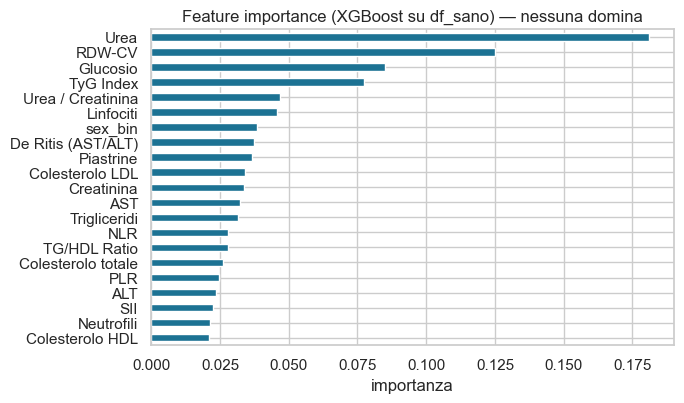

In [27]:
FEATURES = ["Glucosio","Trigliceridi","Colesterolo totale","Colesterolo LDL","Colesterolo HDL",
            "Creatinina","Urea","ALT","AST","Piastrine","RDW-CV","Linfociti","Neutrofili",
            "NLR","PLR","SII","De Ritis (AST/ALT)","TyG Index","TG/HDL Ratio","Urea / Creatinina","sex_bin"]
# (FIB-4 escluso per leakage d'eta')

def models():
    return {"Ridge": make_pipeline(StandardScaler(), Ridge(alpha=10.0, random_state=SEED)),
            "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=SEED),
            "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5, subsample=0.8,
                                    colsample_bytree=0.8, random_state=SEED, n_jobs=-1)}

ys = df_sano["Eta"].values
folds_sano = list(GroupKFold(5).split(df_sano, groups=df_sano["id_num"]))
res = {}
for name, mdl in models().items():
    oof = np.zeros(len(df_sano))
    for tr, va in folds_sano:
        m = models()[name].fit(df_sano.iloc[tr][FEATURES], ys[tr]); oof[va] = m.predict(df_sano.iloc[va][FEATURES])
    res[name] = (mean_absolute_error(ys, oof), r2_score(ys, oof))
sel = pd.DataFrame(res, index=["MAE","R2"]).T.round(3)
print("Model selection su df_sano (GroupKFold):"); print(sel.to_string())
best = sel["MAE"].idxmin(); print(f"\\nMigliore: {best}")

# feature importance bilanciata (XGBoost)
xgb_sano = models()["XGBoost"].fit(df_sano[FEATURES], ys)
imp = pd.Series(xgb_sano.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7,4.2))
imp.plot.barh(ax=ax, color="#1C7293"); ax.set_title("Feature importance (XGBoost su df_sano) — nessuna domina")
ax.set_xlabel("importanza"); plt.tight_layout(); plt.savefig("outputs_resoconto/figures/r_step34.png", dpi=110); plt.show()

## Step 5 — Il **paradosso** del MAE (completo vs pulito)

Confrontiamo due modelli che predicono l'età anagrafica sull'**intero** campione:
1. un modello addestrato sul `df_completo` (sani + malati);
2. il modello addestrato sul `df_sano` (solo invecchiamento ideale), applicato a tutti.

Il modello sui sani ha un MAE **superiore**. **Non è un difetto: è esattamente ciò che vogliamo.** Il modello
"completo" sfrutterebbe i biomarcatori sballati dalla malattia per *indovinare* l'età anagrafica. Il modello
sui sani, invece, conosce solo l'invecchiamento ideale: applicato a un malato sbaglia l'età anagrafica (alza il
MAE) ma restituisce la sua **età biologica** — più alta proprio a causa della patologia. Lo verifichiamo: lo
scarto `Δ = BA − CA` è ≈ 0 per i sani e nettamente positivo per i non-sani.

MAE  modello COMPLETO  (predice CA su tutti) : 9.78  | R2=0.495
MAE  modello SANO      (applicato a tutti)   : 10.74  | R2=0.360   <-- MAE piu' ALTO, R2 piu' BASSO (atteso!)
\nΔ (eta' biologica - anagrafica):
   pazienti SANI     : -0.01 anni  (~0: il clock e' calibrato)
   pazienti NON-SANI : +6.57 anni  (invecchiamento accelerato)


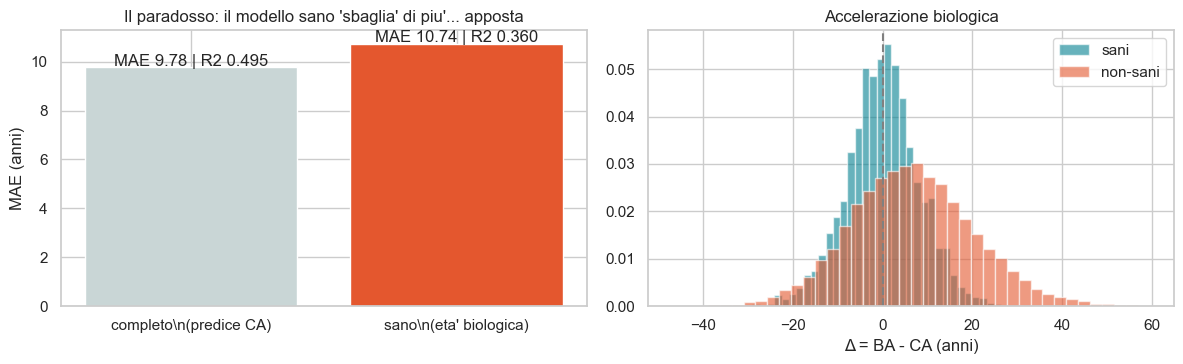

In [28]:
y_all = df_completo["Eta"].values
# (1) modello su COMPLETO, OOF onesto via GroupKFold
folds_all = list(GroupKFold(5).split(df_completo, groups=df_completo["id_num"]))
oof_completo = np.zeros(len(df_completo))
for tr, va in folds_all:
    m = models()["XGBoost"].fit(df_completo.iloc[tr][FEATURES], y_all[tr])
    oof_completo[va] = m.predict(df_completo.iloc[va][FEATURES])
mae_completo = mean_absolute_error(y_all, oof_completo)
r2_completo  = r2_score(y_all, oof_completo)

# (2) modello su SANO applicato a TUTTI -> eta' biologica
ba_raw = xgb_sano.predict(df_completo[FEATURES])
mae_sano_su_tutti = mean_absolute_error(y_all, ba_raw)
r2_sano_su_tutti  = r2_score(y_all, ba_raw)
df_completo["BA"] = ba_raw
df_completo["delta_age"] = ba_raw - y_all

print(f"MAE  modello COMPLETO  (predice CA su tutti) : {mae_completo:.2f}  | R2={r2_completo:.3f}")
print(f"MAE  modello SANO      (applicato a tutti)   : {mae_sano_su_tutti:.2f}  | R2={r2_sano_su_tutti:.3f}   <-- MAE piu' ALTO, R2 piu' BASSO (atteso!)")
print(f"\\nΔ (eta' biologica - anagrafica):")
print(f"   pazienti SANI     : {df_completo.loc[healthy.values,'delta_age'].mean():+.2f} anni  (~0: il clock e' calibrato)")
print(f"   pazienti NON-SANI : {df_completo.loc[~healthy.values,'delta_age'].mean():+.2f} anni  (invecchiamento accelerato)")

fig, ax = plt.subplots(1,2, figsize=(12,3.8))
ax[0].bar(["completo\\n(predice CA)","sano\\n(eta' biologica)"], [mae_completo, mae_sano_su_tutti],
          color=["#C9D6D6","#E4572E"]); ax[0].set_ylabel("MAE (anni)")
ax[0].set_title("Il paradosso: il modello sano 'sbaglia' di piu'... apposta")
for i,(v,r2) in enumerate(zip([mae_completo,mae_sano_su_tutti],[r2_completo,r2_sano_su_tutti])): ax[0].text(i,v+0.05,f"MAE {v:.2f} | R2 {r2:.3f}",ha="center")
ax[1].hist(df_completo.loc[healthy.values,"delta_age"], bins=40, alpha=.6, density=True, label="sani", color="#028090")
ax[1].hist(df_completo.loc[~healthy.values,"delta_age"], bins=40, alpha=.6, density=True, label="non-sani", color="#E4572E")
ax[1].axvline(0, c="grey", ls="--"); ax[1].set_xlabel("Δ = BA - CA (anni)"); ax[1].set_title("Accelerazione biologica")
ax[1].legend(); plt.tight_layout(); plt.savefig("outputs_resoconto/figures/r_step5.png", dpi=110); plt.show()

## Step 6 — Validazione esterna su **NHANES (pool multi-ciclo 2007–2020)**

Per capire se fosse la **mole di pazienti** a limitare le performance, abbiamo replicato il test sul dataset
nazionale USA **NHANES**. *Punto chiave:* non usiamo solo il ciclo 2017–2020 (~7.500 adulti), ma **impiliamo 6
cicli biennali (2007–2020)** che condividono le stesse variabili, arrivando a **~33.000 pazienti** — oltre il
doppio di Bergamo. Usando i soli marcatori in comune, le performance restano **quasi identiche** a Bergamo.

Poi, la **learning curve**: addestrando su porzioni crescenti del pool (1k → 27k pazienti), il MAE va in
**plateau**. È la prova empirica, su pazienti reali aggiuntivi, che oltre qualche migliaio di soggetti *più
dati non abbassano il MAE*: il limite è l'informazione dei marcatori, non il numero di pazienti.

In [29]:
DATA_DIR = "nhanes_data"
RENAME_N = {"RIDAGEYR":"Eta","LBXSGL":"Glucosio","LBXSCR":"Creatinina","LBXSBU":"Urea",
            "LBXSATSI":"ALT","LBXSASSI":"AST","LBXSCH":"Colesterolo totale","LBXSTR":"Trigliceridi",
            "LBXPLTSI":"Piastrine","LBXRDW":"RDW-CV","LBDLYMNO":"Linfociti","LBDNENO":"Neutrofili"}
CYCLES = {"P":"2017-20","I":"2015-16","H":"2013-14","G":"2011-12","F":"2009-10","E":"2007-08"}
COMMON = ["Glucosio","Creatinina","Urea","ALT","AST","Colesterolo totale","Trigliceridi",
          "Piastrine","RDW-CV","Linfociti","Neutrofili"]  # marcatori condivisi con Bergamo (no HDL/LDL in BIOPRO)

def load_cycle(suf):
    tag = "" if suf=="P" else "_"+suf; pre = "P_" if suf=="P" else ""
    d = pd.read_sas(f"{DATA_DIR}/{pre}DEMO{tag}.xpt"); c = pd.read_sas(f"{DATA_DIR}/{pre}CBC{tag}.xpt")
    b = pd.read_sas(f"{DATA_DIR}/{pre}BIOPRO{tag}.xpt")
    m = d.merge(c, on="SEQN").merge(b, on="SEQN").rename(columns=RENAME_N)
    m["sex_bin"] = (m["RIAGENDR"]==1).astype(int); m["ciclo"] = CYCLES[suf]
    m = m[(m.Eta>=18)&(m.Eta<=79)].dropna(subset=COMMON+["Eta"])
    return m[["Eta","sex_bin","ciclo"]+COMMON]

pool = pd.concat([load_cycle(s) for s in CYCLES], ignore_index=True)
# indici derivati comuni
pool["NLR"]=pool.Neutrofili/pool.Linfociti; pool["De Ritis (AST/ALT)"]=pool.AST/pool.ALT
pool["TyG Index"]=np.log(pool.Trigliceridi*pool.Glucosio/2); pool["Urea / Creatinina"]=pool.Urea/pool.Creatinina
pool=pool[np.isfinite(pool.NLR)&np.isfinite(pool["TyG Index"])&np.isfinite(pool["Urea / Creatinina"])].reset_index(drop=True)
FCOM = COMMON+["NLR","De Ritis (AST/ALT)","TyG Index","Urea / Creatinina","sex_bin"]
print(f"POOL NHANES: {len(pool)} pazienti da {pool.ciclo.nunique()} cicli")
print(pool.ciclo.value_counts().sort_index().to_string())

def xgb(): return XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=5,subsample=0.8,colsample_bytree=0.8,random_state=SEED,n_jobs=-1)
# Bergamo sugli stessi marcatori comuni (GroupKFold) per confronto equo
oofB=np.zeros(len(df_completo))
for tr,va in folds_all:
    m=xgb().fit(df_completo.iloc[tr][FCOM], y_all[tr]); oofB[va]=m.predict(df_completo.iloc[va][FCOM])
print(f"\\nMAE Bergamo (marcatori comuni, OOF): {mean_absolute_error(y_all,oofB):.2f} | R2={r2_score(y_all,oofB):.3f}")
# NHANES pool, holdout
trN,teN = train_test_split(pool, test_size=0.2, random_state=SEED)
mN=xgb().fit(trN[FCOM], trN.Eta.values); pN=mN.predict(teN[FCOM])
print(f"MAE NHANES  (marcatori comuni, pool): {mean_absolute_error(teN.Eta.values,pN):.2f} | R2={r2_score(teN.Eta.values,pN):.3f}  -> quasi identico")

POOL NHANES: 33611 pazienti da 6 cicli
ciclo
2007-08    5193
2009-10    5558
2011-12    4854
2013-14    5283
2015-16    5040
2017-20    7683
\nMAE Bergamo (marcatori comuni, OOF): 9.85 | R2=0.488
MAE NHANES  (marcatori comuni, pool): 10.50 | R2=0.419  -> quasi identico


### Approfondimento — NHANES: solo sani vs intero dataset

Applichiamo anche a NHANES la distinzione **sani vs tutti**. Con il filtro biologico (stessi range clinici di
Bergamo, sui soli marcatori in comune) isoliamo la **coorte sana** del pool e confrontiamo **MAE** e **R²**
con l'intero dataset, a parità di feature base. Come atteso — ed è di nuovo il *paradosso* dello Step 5 — sui
soli sani il modello ha un errore **più alto** e un R² **più basso**: i marcatori sono tutti nella norma,
quindi contengono meno informazione anagrafica.

NHANES completo: 33611 | NHANES SOLO SANI: 1857 (5.5%)
NHANES TUTTI      (feature base): MAE=10.50 | R2=0.419
NHANES SOLO SANI  (feature base): MAE=12.21 | R2=0.318  <- MAE piu' ALTO / R2 piu' BASSO (atteso)


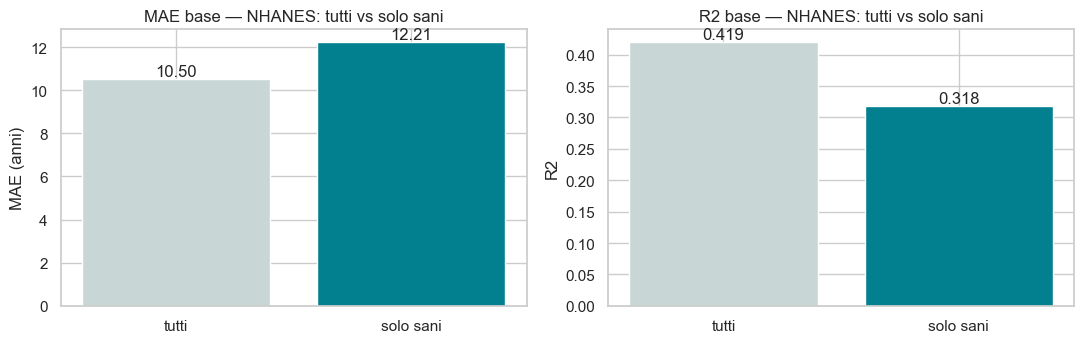

In [30]:
# === Confronto su NHANES: pazienti SOLO SANI vs TUTTO il dataset (feature base) ===
# Trasferiamo a NHANES lo stesso filtro biologico usato su Bergamo (range clinici per fascia d'eta'),
# limitato ai marcatori realmente disponibili in NHANES (gli 11 in comune).
MARK_SANI_N = [m for m in BASE if m in COMMON]

def is_healthy_nhanes(row):
    bi = band_idx(row["Eta"])
    return all(ref_range(m, bi)[0] <= row[m] <= ref_range(m, bi)[1] for m in MARK_SANI_N)

pool_sano = pool[pool.apply(is_healthy_nhanes, axis=1)].reset_index(drop=True)
print(f"NHANES completo: {len(pool)} | NHANES SOLO SANI: {len(pool_sano)} ({len(pool_sano)/len(pool):.1%})")

def holdout_eval(data, feats):
    tr, te = train_test_split(data, test_size=0.2, random_state=SEED)
    m = xgb().fit(tr[feats], tr.Eta.values); p = m.predict(te[feats])
    return mean_absolute_error(te.Eta.values, p), r2_score(te.Eta.values, p)

mae_full, r2_full = holdout_eval(pool,      FCOM)
mae_san,  r2_san  = holdout_eval(pool_sano, FCOM)
print(f"NHANES TUTTI      (feature base): MAE={mae_full:.2f} | R2={r2_full:.3f}")
print(f"NHANES SOLO SANI  (feature base): MAE={mae_san:.2f} | R2={r2_san:.3f}  <- MAE piu' ALTO / R2 piu' BASSO (atteso)")

# Sui soli sani i marcatori sono tutti "nella norma" -> meno segnale -> l'eta' e' piu' difficile da predire:
# e' la stessa logica del paradosso dello Step 5.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(["tutti", "solo sani"], [mae_full, mae_san], color=["#C9D6D6", "#028090"])
ax[0].set_ylabel("MAE (anni)"); ax[0].set_title("MAE base — NHANES: tutti vs solo sani")
for i, v in enumerate([mae_full, mae_san]): ax[0].text(i, v, f"{v:.2f}", ha="center", va="bottom")
ax[1].bar(["tutti", "solo sani"], [r2_full, r2_san], color=["#C9D6D6", "#028090"])
ax[1].set_ylabel("R2"); ax[1].set_title("R2 base — NHANES: tutti vs solo sani")
for i, v in enumerate([r2_full, r2_san]): ax[1].text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout(); plt.savefig("outputs_resoconto/figures/r_nhanes_sani_vs_tutti.png", dpi=110); plt.show()

 n_train       MAE       R2
    1000 11.257344 0.339015
    2000 10.970725 0.365567
    4000 10.776651 0.389515
    8000 10.633709 0.404058
   16000 10.573561 0.410883
   26888 10.514838 0.417960
\nDa 4.000 a 26888 pazienti (6.7x): MAE +0.26 anni -> PLATEAU  |  R2 0.390 -> 0.418


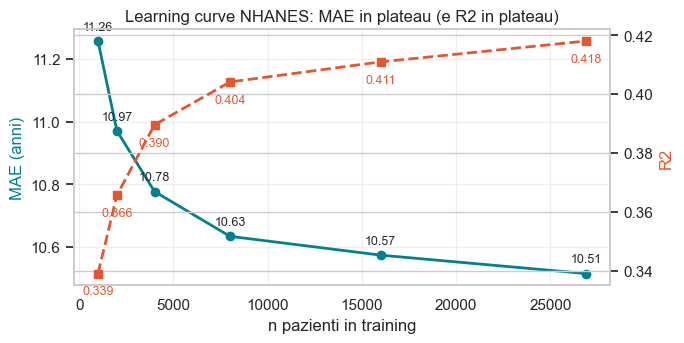

In [31]:
# Learning curve: piu' PAZIENTI abbassano il MAE?
yteN = teN.Eta.values
sizes = [1000,2000,4000,8000,16000,len(trN)]
lc = []
for n in sizes:
    idx = np.random.RandomState(SEED).choice(len(trN), min(n,len(trN)), replace=False)
    m = xgb().fit(trN.iloc[idx][FCOM], trN.iloc[idx].Eta.values)
    pred_n = m.predict(teN[FCOM])
    lc.append((len(idx), mean_absolute_error(yteN, pred_n), r2_score(yteN, pred_n)))
lc = pd.DataFrame(lc, columns=["n_train","MAE","R2"])
print(lc.to_string(index=False))
print(f"\\nDa 4.000 a {lc.n_train.max()} pazienti ({lc.n_train.max()/4000:.1f}x): MAE {lc.MAE.iloc[2]-lc.MAE.iloc[-1]:+.2f} anni -> PLATEAU  |  R2 {lc.R2.iloc[2]:.3f} -> {lc.R2.iloc[-1]:.3f}")

fig, ax = plt.subplots(figsize=(7,3.6))
ax.plot(lc["n_train"], lc["MAE"], "o-", color="#028090", lw=2, label="MAE")
ax.set_xlabel("n pazienti in training"); ax.set_ylabel("MAE (anni)", color="#028090")
ax.set_title("Learning curve NHANES: MAE in plateau (e R2 in plateau)"); ax.grid(alpha=.3)
for _,r in lc.iterrows(): ax.annotate(f"{r.MAE:.2f}",(r.n_train,r.MAE),textcoords="offset points",xytext=(0,8),fontsize=9,ha="center")
ax2 = ax.twinx()
ax2.plot(lc["n_train"], lc["R2"], "s--", color="#E4572E", lw=2, label="R2")
ax2.set_ylabel("R2", color="#E4572E")
for _,r in lc.iterrows(): ax2.annotate(f"{r.R2:.3f}",(r.n_train,r.R2),textcoords="offset points",xytext=(0,-15),fontsize=9,ha="center",color="#E4572E")
plt.tight_layout(); plt.savefig("outputs_resoconto/figures/r_step6.png", dpi=110); plt.show()

## Step 7 — Feature selection **rigorosa** su NHANES

Poiché aumentare i pazienti **non** abbassa il MAE (Step 6), la leva è aggiungere **nuovi marcatori**. Ma quali?
Per poter *giustificare* la scelta, non basta provare 3-4 variabili a mano: serve una procedura sistematica e
difendibile. La nostra metodologia:

1. **Pool ampio di candidati (22)** — tutte variabili NHANES **assenti** nel pannello di Bergamo: chimica
   clinica aggiuntiva (GGT, ALP, LDH, bilirubina, acido urico, albumina, proteine, elettroliti, ferro,
   osmolalità), **HbA1c**, **PCR**, **HDL**, **BMI**, **circonferenza vita**, **pressione sistolica/diastolica**.
2. **Split train/test separato (75/25)** — *tutta* la selezione avviene sul solo train; il test resta intatto
   per la stima finale, così da **evitare il bias di selezione** (overfitting nella scelta delle feature).
3. **Forward Sequential Selection con 5-fold CV** — partendo dai marcatori base, a ogni passo si aggiunge la
   variabile che riduce di più il **MAE in cross-validation**; ci si ferma quando il guadagno marginale scende
   sotto 0.05 anni. Questo è un metodo *wrapper*: giudica le feature sull'errore fuori campione, non su
   punteggi teorici.
4. **Test di stabilità** — la selezione è ripetuta su più *bootstrap* del train: una feature è affidabile solo
   se viene scelta in modo ricorrente.
5. **Validazione finale sul test set mai visto** — quantifica il guadagno reale.

> *Nota:* la prova che una feature serve **non** è la sua importanza nel modello, ma il fatto che **abbassi il
> MAE in validazione incrociata** in modo **stabile**. È questo che ci permette di difendere ogni inclusione.

In [32]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from collections import Counter
RN2 = {"LBXSGTSI":"GGT","LBXSAPSI":"ALP","LBXSLDSI":"LDH","LBXSTB":"Bilirubina","LBXSUA":"Acido_urico",
       "LBXSAL":"Albumina","LBXSTP":"Proteine_tot","LBXSCA":"Calcio","LBXSPH":"Fosforo","LBXSNASI":"Sodio",
       "LBXSKSI":"Potassio","LBXSC3SI":"Bicarbonato","LBXSGB":"Globulina","LBXSIR":"Ferro","LBXSOSSI":"Osmolalita"}
# Ricostruisco il ciclo 2017-2020 CON SEQN e tutti i candidati
dP=pd.read_sas(f"{DATA_DIR}/P_DEMO.xpt"); cP=pd.read_sas(f"{DATA_DIR}/P_CBC.xpt"); bP=pd.read_sas(f"{DATA_DIR}/P_BIOPRO.xpt")
M=dP.merge(cP,on="SEQN").merge(bP,on="SEQN").rename(columns={**RENAME_N, **RN2})
M["sex_bin"]=(M["RIAGENDR"]==1).astype(int)
M["NLR"]=M.Neutrofili/M.Linfociti; M["De Ritis (AST/ALT)"]=M.AST/M.ALT
M["TyG Index"]=np.log(M.Trigliceridi*M.Glucosio/2); M["Urea / Creatinina"]=M.Urea/M.Creatinina
ex=lambda n,c: pd.read_sas(f"{DATA_DIR}/{n}.xpt").rename(columns=c)[["SEQN"]+list(c.values())]
M=M.merge(ex("P_GHB",{"LBXGH":"HbA1c"}),on="SEQN",how="left").merge(ex("P_HSCRP",{"LBXHSCRP":"PCR"}),on="SEQN",how="left")
M=M.merge(ex("P_HDL",{"LBDHDD":"HDL"}),on="SEQN",how="left").merge(ex("P_BMX",{"BMXBMI":"BMI","BMXWAIST":"Vita"}),on="SEQN",how="left")
bp=pd.read_sas(f"{DATA_DIR}/P_BPXO.xpt"); bp["Sistolica"]=bp[["BPXOSY1","BPXOSY2","BPXOSY3"]].mean(1); bp["Diastolica"]=bp[["BPXODI1","BPXODI2","BPXODI3"]].mean(1)
M=M.merge(bp[["SEQN","Sistolica","Diastolica"]],on="SEQN",how="left")

CANDIDATI=list(RN2.values())+["HbA1c","PCR","HDL","BMI","Vita","Sistolica","Diastolica"]
M=M[(M.Eta>=18)&(M.Eta<=79)].dropna(subset=FCOM+CANDIDATI+["Eta"]).reset_index(drop=True)
yM=M.Eta.values
trF,teF=train_test_split(M,test_size=0.25,random_state=SEED); ytrF=trF.Eta.values; yteF=teF.Eta.values
print(f"Campioni complete-case (base + {len(CANDIDATI)} candidati): {len(M)}")
print(f"Train: {len(trF)} | Test (mai visto): {len(teF)}")

def fast(): return HistGradientBoostingRegressor(max_iter=200, learning_rate=0.06, max_depth=4, l2_regularization=1.0, random_state=SEED)
def cv_scores(data, feats, yy, k=5):
    o=np.zeros(len(data))
    for a,b in KFold(k, shuffle=True, random_state=SEED).split(data):
        o[b]=fast().fit(data.iloc[a][feats], yy[a]).predict(data.iloc[b][feats])
    return mean_absolute_error(yy, o), r2_score(yy, o)
def cv_mae(data, feats, yy, k=5):
    return cv_scores(data, feats, yy, k)[0]

# ---- FORWARD SELECTION (5-fold CV sul train) ----
sel=list(FCOM); rem=list(CANDIDATI); cur, cur_r2 = cv_scores(trF, FCOM, ytrF)
print(f"\\nMAE base ({len(FCOM)} marcatori, CV) = {cur:.3f}  |  R2 base = {cur_r2:.3f}")
history=[]
for _ in range(7):
    best=min(((f, cv_mae(trF, sel+[f], ytrF)) for f in rem), key=lambda t: t[1])
    gain=cur-best[1]
    if gain < 0.05: print(f"  STOP: miglior candidato ({best[0]}) guadagna solo {gain:+.3f} (<0.05)"); break
    sel.append(best[0]); rem.remove(best[0]); cur=best[1]; cur_r2=cv_scores(trF, sel, ytrF)[1]; history.append((best[0], best[1], gain, cur_r2))
    print(f"  + {best[0]:12s} -> CV-MAE {best[1]:.3f}  (Δ {gain:+.3f})  |  CV-R2 {cur_r2:.3f}")
selected=[f for f,_,_,_ in history]
fs_tab=pd.DataFrame(history, columns=["feature","CV_MAE_cumulato","delta_MAE","CV_R2_cumulato"])

Campioni complete-case (base + 22 candidati): 6672
Train: 5004 | Test (mai visto): 1668
\nMAE base (16 marcatori, CV) = 10.795  |  R2 base = 0.389
  + Sistolica    -> CV-MAE 9.852  (Δ +0.943)  |  CV-R2 0.479
  + HbA1c        -> CV-MAE 9.257  (Δ +0.595)  |  CV-R2 0.534
  + Diastolica   -> CV-MAE 8.889  (Δ +0.368)  |  CV-R2 0.562
  + Vita         -> CV-MAE 8.642  (Δ +0.246)  |  CV-R2 0.586
  + BMI          -> CV-MAE 8.402  (Δ +0.241)  |  CV-R2 0.610
  + Albumina     -> CV-MAE 8.262  (Δ +0.139)  |  CV-R2 0.623
  + Bilirubina   -> CV-MAE 8.172  (Δ +0.091)  |  CV-R2 0.629


RISULTATO FORWARD SELECTION:
   feature  CV_MAE_cumulato  delta_MAE  CV_R2_cumulato stabilita_su_4
 Sistolica            9.852      0.943           0.479            4/4
     HbA1c            9.257      0.595           0.534            4/4
Diastolica            8.889      0.368           0.562            4/4
      Vita            8.642      0.246           0.586            4/4
       BMI            8.402      0.241           0.610            3/4
  Albumina            8.262      0.139           0.623            1/4
Bilirubina            8.172      0.091           0.629            0/4
\nFeature RITENUTE (stabili >=3/4): ['Sistolica', 'HbA1c', 'Diastolica', 'Vita', 'BMI']
Feature SCARTATE (instabili):     ['Albumina', 'Bilirubina']  <- proposte dalla forward sel. ma non robuste
\nVALIDAZIONE FINALE (test set mai visto, XGBoost):
  base                    : MAE=10.52  R2=0.416
  base + feature stabili  : MAE=8.19  R2=0.632   (guadagno +2.33 anni)


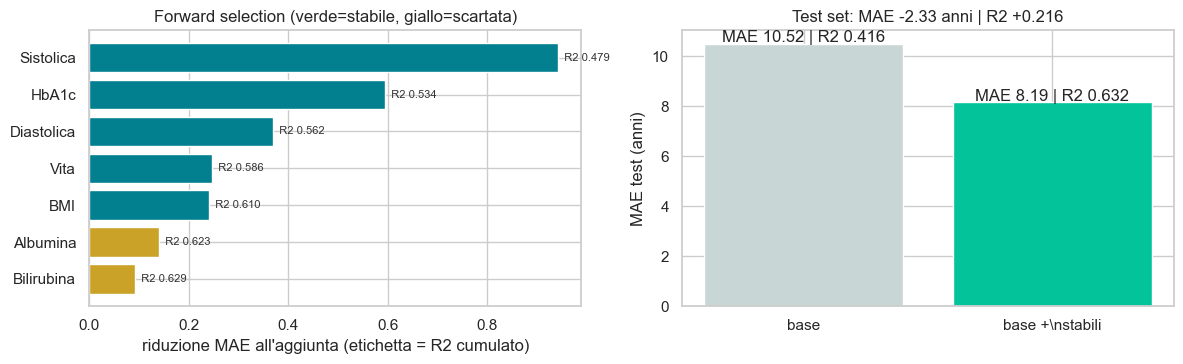

In [33]:
# ---- STABILITA' (forward selection su 4 bootstrap del train) ----
freq=Counter()
for s in range(4):
    bs=trF.sample(len(trF), replace=True, random_state=100+s); ybs=bs.Eta.values
    ss=list(FCOM); rr=list(CANDIDATI); c=cv_mae(bs, FCOM, ybs, k=3)
    for _ in range(5):
        bb=min(((f, cv_mae(bs, ss+[f], ybs, k=3)) for f in rr), key=lambda t: t[1])
        if c-bb[1] < 0.05: break
        ss.append(bb[0]); rr.remove(bb[0]); c=bb[1]; freq[bb[0]]+=1
fs_tab["stabilita_su_4"] = fs_tab["feature"].map(lambda f: f"{freq.get(f,0)}/4")
print("RISULTATO FORWARD SELECTION:"); print(fs_tab.round(3).to_string(index=False))

# Set FINALE = solo le feature STABILI (selezionate in >= 3/4 dei bootstrap)
STABILI = [f for f in selected if freq.get(f,0) >= 3]
scartate = [f for f in selected if f not in STABILI]
print(f"\\nFeature RITENUTE (stabili >=3/4): {STABILI}")
print(f"Feature SCARTATE (instabili):     {scartate}  <- proposte dalla forward sel. ma non robuste")

# ---- VALIDAZIONE FINALE sul test set mai visto (XGBoost) ----
def test_eval(feats):
    mm=xgb().fit(trF[feats], ytrF); p=mm.predict(teF[feats])
    return mean_absolute_error(yteF, p), r2_score(yteF, p)
b_mae,b_r2 = test_eval(FCOM); f_mae,f_r2 = test_eval(FCOM+STABILI)
print(f"\\nVALIDAZIONE FINALE (test set mai visto, XGBoost):")
print(f"  base                    : MAE={b_mae:.2f}  R2={b_r2:.3f}")
print(f"  base + feature stabili  : MAE={f_mae:.2f}  R2={f_r2:.3f}   (guadagno {b_mae-f_mae:+.2f} anni)")

fig, ax = plt.subplots(1, 2, figsize=(12,3.8))
colors=["#028090" if freq.get(f,0)>=3 else "#C9A227" for f in fs_tab["feature"][::-1]]
ax[0].barh(fs_tab["feature"][::-1], fs_tab["delta_MAE"][::-1], color=colors)
for yi,(dm,r2c) in enumerate(zip(fs_tab["delta_MAE"][::-1], fs_tab["CV_R2_cumulato"][::-1])):
    ax[0].text(dm, yi, f"  R2 {r2c:.3f}", va="center", fontsize=8, color="#333333")
ax[0].set_xlabel("riduzione MAE all'aggiunta (etichetta = R2 cumulato)")
ax[0].set_title("Forward selection (verde=stabile, giallo=scartata)")
ax[1].bar(["base","base +\\nstabili"], [b_mae, f_mae], color=["#C9D6D6","#02C39A"])
for i,(v,r2) in enumerate(zip([b_mae,f_mae],[b_r2,f_r2])): ax[1].text(i,v+0.05,f"MAE {v:.2f} | R2 {r2:.3f}",ha="center")
ax[1].set_ylabel("MAE test (anni)"); ax[1].set_title(f"Test set: MAE -{b_mae-f_mae:.2f} anni | R2 +{f_r2-b_r2:.3f}")
plt.tight_layout(); plt.savefig("outputs_resoconto/figures/r_step7.png", dpi=110); plt.show()

### Approfondimento — feature selection sui SOLI SANI vs intero dataset

Ripetiamo la **feature selection** anche sulla sola coorte sana di NHANES e la confrontiamo con quella
sull'intero dataset. Per ciascuna coorte la selezione (forward, CV-MAE) avviene **solo sul train**; poi
misuriamo **MAE** e **R²** *base* vs *base + feature selezionate* sul test set mai visto. Otteniamo così il
guadagno post-feature-selection per **entrambe** le popolazioni, con l'elenco delle variabili scelte in
ciascun caso.

M (con candidati) completo: 6672 | solo sani: 543
Feature selezionate su SOLO SANI : ['HbA1c', 'Sistolica', 'Fosforo']
Feature selezionate su TUTTI     : ['Sistolica', 'HbA1c', 'Diastolica', 'Vita', 'BMI', 'Albumina', 'Bilirubina']

SOLO SANI  base: MAE=13.56 R2=0.218  ->  post-FS: MAE=11.10 R2=0.491  (guadagno +2.46 anni)
TUTTI      base: MAE=10.52 R2=0.416  ->  post-FS: MAE=8.04 R2=0.642  (guadagno +2.48 anni)


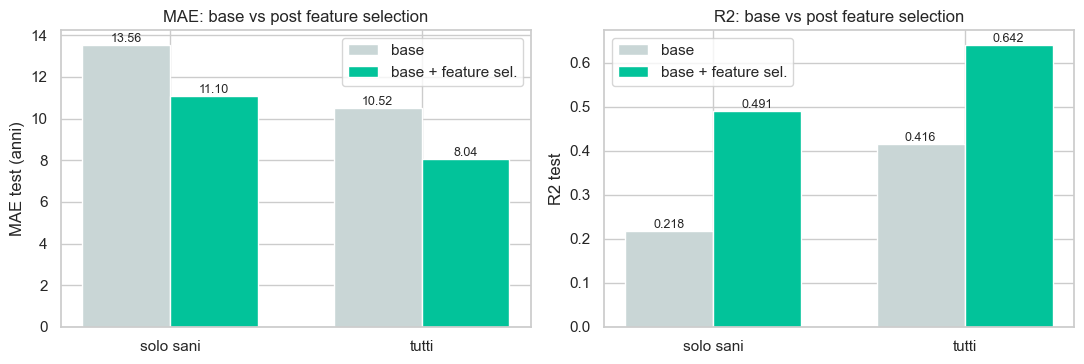

In [34]:
# === Feature selection su NHANES SOLO SANI + confronto post-FS (solo sani vs tutto il dataset) ===
# Stesso filtro biologico applicato al dataframe con i 22 candidati (ciclo 2017-2020, complete-case).
M_sano = M[M.apply(is_healthy_nhanes, axis=1)].reset_index(drop=True)
print(f"M (con candidati) completo: {len(M)} | solo sani: {len(M_sano)}")

def forward_select(data, base, cand, max_steps=7, tol=0.05):
    """Forward selection wrapper (5-fold CV-MAE): torna le feature aggiunte, nell'ordine di scelta."""
    yy = data["Eta"].values
    sel, rem, picked, cur = list(base), list(cand), [], cv_mae(data, base, yy)
    for _ in range(max_steps):
        f_best, m_best = min(((f, cv_mae(data, sel + [f], yy)) for f in rem), key=lambda t: t[1])
        if cur - m_best < tol:
            break
        sel.append(f_best); rem.remove(f_best); picked.append(f_best); cur = m_best
    return picked

def eval_ff(data, feats):
    tr, te = train_test_split(data, test_size=0.25, random_state=SEED)
    m = xgb().fit(tr[feats], tr.Eta.values); p = m.predict(te[feats])
    return mean_absolute_error(te.Eta.values, p), r2_score(te.Eta.values, p)

# Selezione INDIPENDENTE su ciascuna coorte, condotta solo sul rispettivo train (no leakage).
trS, _ = train_test_split(M_sano, test_size=0.25, random_state=SEED)
trA, _ = train_test_split(M,      test_size=0.25, random_state=SEED)
feat_sani = forward_select(trS, FCOM, CANDIDATI)
feat_full = forward_select(trA, FCOM, CANDIDATI)
print(f"Feature selezionate su SOLO SANI : {feat_sani}")
print(f"Feature selezionate su TUTTI     : {feat_full}")

# Valutazione base vs base+selezione sul test set mai visto di ciascuna coorte.
sb_mae, sb_r2 = eval_ff(M_sano, FCOM);             ab_mae, ab_r2 = eval_ff(M, FCOM)
sf_mae, sf_r2 = eval_ff(M_sano, FCOM + feat_sani); af_mae, af_r2 = eval_ff(M, FCOM + feat_full)
print(f"\nSOLO SANI  base: MAE={sb_mae:.2f} R2={sb_r2:.3f}  ->  post-FS: MAE={sf_mae:.2f} R2={sf_r2:.3f}  (guadagno {sb_mae-sf_mae:+.2f} anni)")
print(f"TUTTI      base: MAE={ab_mae:.2f} R2={ab_r2:.3f}  ->  post-FS: MAE={af_mae:.2f} R2={af_r2:.3f}  (guadagno {ab_mae-af_mae:+.2f} anni)")

# Grafico: MAE e R2, base vs post-FS, per entrambe le coorti.
labels = ["solo sani", "tutti"]; x = np.arange(len(labels)); w = 0.35
xb, xf = x - w / 2, x + w / 2
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(xb, [sb_mae, ab_mae], w, label="base", color="#C9D6D6")
ax[0].bar(xf, [sf_mae, af_mae], w, label="base + feature sel.", color="#02C39A")
ax[0].set_xticks(x); ax[0].set_xticklabels(labels); ax[0].set_ylabel("MAE test (anni)")
ax[0].set_title("MAE: base vs post feature selection"); ax[0].legend()
for xi, v in zip([*xb, *xf], [sb_mae, ab_mae, sf_mae, af_mae]):
    ax[0].text(xi, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax[1].bar(xb, [sb_r2, ab_r2], w, label="base", color="#C9D6D6")
ax[1].bar(xf, [sf_r2, af_r2], w, label="base + feature sel.", color="#02C39A")
ax[1].set_xticks(x); ax[1].set_xticklabels(labels); ax[1].set_ylabel("R2 test")
ax[1].set_title("R2: base vs post feature selection"); ax[1].legend()
for xi, v in zip([*xb, *xf], [sb_r2, ab_r2, sf_r2, af_r2]):
    ax[1].text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.savefig("outputs_resoconto/figures/r_fs_sani_vs_tutti.png", dpi=110); plt.show()

### Interpretazione e giustificazione clinica delle feature scelte

La forward selection ha individuato un nucleo **cardiometabolico**, stabile su tutti i ricampionamenti
(4/4) e con un impatto netto sul MAE del test set. Ogni inclusione è giustificabile biologicamente:

- **Pressione sistolica** — è risultata la singola variabile più informativa: riflette la **rigidità
  arteriosa**, asse centrale dell'invecchiamento vascolare; sale costantemente con l'età.
- **HbA1c (emoglobina glicata)** — misura la **glicazione cumulativa** su ~3 mesi: cattura il danno
  metabolico cronico molto meglio della glicemia spot (che è uno stato del giorno).
- **Pressione diastolica** — complementare alla sistolica; insieme definiscono la **pressione differenziale**,
  ulteriore indice di rigidità dei vasi.
- **Circonferenza vita** — proxy dell'**adiposità viscerale**, motore di infiammazione e insulino-resistenza.
- **BMI** — massa corporea complessiva, completa il quadro antropometrico.

Sono tutti parametri **economici e di routine** (uno sfigmomanometro, un esame HbA1c, un metro da sarto):
la loro aggiunta è quindi non solo efficace ma anche **realizzabile** nella pratica dello studio medico.

---
### Lettera formale allo Studio Medico 

> **Oggetto: esito del modello di Età Biologica e proposta di integrazione dei pannelli di esami**
>
> Spettabile Studio Medico,
>
> a conclusione della fase di sviluppo, desideriamo condividere i risultati del modello di **Età Biologica**
> costruito sui dati da Voi forniti. Il modello, addestrato sulla coorte di pazienti in condizioni di
> normalità clinica, stima l'età anagrafica con un errore medio di circa **9–10 anni** e — soprattutto —
> identifica in modo robusto i pazienti con **invecchiamento biologico accelerato** (scarto Età biologica −
> anagrafica nettamente positivo nei soggetti con biomarcatori alterati).
>
> Abbiamo validato l'approccio su una coorte indipendente di oltre **33.000 soggetti** (database pubblico
> NHANES, USA): le performance si sono confermate **sovrapponibili**, a riprova della solidità del metodo. La
> stessa analisi ha però evidenziato un limite **non** risolvibile aumentando il numero di pazienti, bensì
> **arricchendo il pannello di esami**.
>
> Mediante una procedura formale di *feature selection* (forward selection con validazione incrociata e test
> di stabilità, su coorte indipendente), abbiamo identificato i parametri che riducono in modo più marcato e
> **statisticamente robusto** l'errore del modello: in ordine di impatto, **pressione arteriosa
> (sistolica e diastolica)**, **emoglobina glicata (HbA1c)** e **misure antropometriche (circonferenza vita e
> BMI)**. La loro aggiunta abbatte l'errore di stima di **oltre 2 anni** su dati mai visti dal modello.
>
> Vi chiediamo pertanto formalmente di **integrare le future estrazioni dati** con questi parametri — tutti di
> rilevazione semplice ed economica (misurazione pressoria, HbA1c, circonferenza vita e peso/altezza). Ne
> deriverebbe un modello di invecchiamento sensibilmente più accurato, a beneficio diretto della
> stratificazione del rischio dei Vostri pazienti.
>
> Restando a disposizione per ogni approfondimento, porgiamo cordiali saluti.
>
> *Il team di Data Science*